---
# Fase 8 — Tratamento do Desbalanceamento

**Objetivo:** Investigar se o desbalanceamento de classes (71,4% para a classe 1 e 28,6% para a classe 0) prejudica a performance dos modelos. Vamos comparar diferentes estratégias de tratamento para identificar a melhor abordagem.

**Experimentos Planejados:**
- **Exp 1: Baseline** (Sem tratamento).
- **Exp 2: Ajuste de Pesos (`class_weight`)** (Ponderação interna dos modelos).
- **Exp 3: SMOTE** (Geração de amostras sintéticas para a classe minoritária, utilizando a pipeline do `imblearn` para evitar *data leakage*).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Carregar dados
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')['Dataset']

colunas_numericas = list(X_train.columns)

# Preprocessors
preprocessor_scaled = joblib.load('models/preprocessor_scaled.joblib')
preprocessor_unscaled = joblib.load('models/preprocessor_unscaled.joblib')

# Precisamos usar a Pipeline do imblearn para suportar o SMOTE sem vazamento de dados
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def criar_pipeline_experimento(modelo, usar_scaler=True, usar_smote=False):
    if usar_scaler:
        pre = ColumnTransformer(transformers=[
            ('num', ImbPipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), colunas_numericas)
        ])
    else:
        pre = ColumnTransformer(transformers=[
            ('num', ImbPipeline(steps=[
                ('imputer', SimpleImputer(strategy='median'))
            ]), colunas_numericas)
        ])
    
    steps = [('preprocessor', pre)]
    
    if usar_smote:
        steps.append(('smote', SMOTE(random_state=42)))
        
    steps.append(('classifier', modelo))
    
    return ImbPipeline(steps=steps)

# Razão de classes para o XGBoost (negativo / positivo = classe 0 / classe 1)
# O target é 1 (Doença) e 0 (Saudável)
ratio = sum(y_train == 0) / sum(y_train == 1)

print('Setup concluído. Prontos para os experimentos!')

Setup concluído. Prontos para os experimentos!


## 8.1 — Configuração dos 3 Experimentos para os 6 Modelos

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

experimentos = {}

# 1. Regressão Logística
experimentos['LR_Baseline'] = criar_pipeline_experimento(LogisticRegression(random_state=42, max_iter=1000), usar_scaler=True)
experimentos['LR_Weight'] = criar_pipeline_experimento(LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'), usar_scaler=True)
experimentos['LR_SMOTE'] = criar_pipeline_experimento(LogisticRegression(random_state=42, max_iter=1000), usar_scaler=True, usar_smote=True)

# 2. KNN (Não tem class_weight nativo, usamos weights='distance')
experimentos['KNN_Baseline'] = criar_pipeline_experimento(KNeighborsClassifier(), usar_scaler=True)
experimentos['KNN_Weight'] = criar_pipeline_experimento(KNeighborsClassifier(weights='distance'), usar_scaler=True)
experimentos['KNN_SMOTE'] = criar_pipeline_experimento(KNeighborsClassifier(), usar_scaler=True, usar_smote=True)

# 3. SVM
experimentos['SVM_Baseline'] = criar_pipeline_experimento(SVC(probability=True, random_state=42), usar_scaler=True)
experimentos['SVM_Weight'] = criar_pipeline_experimento(SVC(probability=True, random_state=42, class_weight='balanced'), usar_scaler=True)
experimentos['SVM_SMOTE'] = criar_pipeline_experimento(SVC(probability=True, random_state=42), usar_scaler=True, usar_smote=True)

# 4. Random Forest
experimentos['RF_Baseline'] = criar_pipeline_experimento(RandomForestClassifier(random_state=42), usar_scaler=False)
experimentos['RF_Weight'] = criar_pipeline_experimento(RandomForestClassifier(random_state=42, class_weight='balanced'), usar_scaler=False)
experimentos['RF_SMOTE'] = criar_pipeline_experimento(RandomForestClassifier(random_state=42), usar_scaler=False, usar_smote=True)

# 5. XGBoost
experimentos['XGB_Baseline'] = criar_pipeline_experimento(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), usar_scaler=False)
experimentos['XGB_Weight'] = criar_pipeline_experimento(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio), usar_scaler=False)
experimentos['XGB_SMOTE'] = criar_pipeline_experimento(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), usar_scaler=False, usar_smote=True)

# 6. MLP (Não suporta class_weight nativo. Faremos apenas Baseline e SMOTE)
experimentos['MLP_Baseline'] = criar_pipeline_experimento(MLPClassifier(random_state=42, early_stopping=True, max_iter=1000), usar_scaler=True)
experimentos['MLP_SMOTE'] = criar_pipeline_experimento(MLPClassifier(random_state=42, early_stopping=True, max_iter=1000), usar_scaler=True, usar_smote=True)

print(f'Total de configurações a testar: {len(experimentos)}')

Total de configurações a testar: 17


## 8.2 — Avaliação via Validação Cruzada (CV)

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}

print('Rodando experimentos (isso pode levar cerca de 1 a 2 minutos)...\n')

for nome, pipeline in experimentos.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    resultados_cv[nome] = scores
    print(f'✓ {nome} concluído')

print('\nAvaliação de todos os experimentos concluída!')

Rodando experimentos (isso pode levar cerca de 1 a 2 minutos)...



✓ LR_Baseline concluído


✓ LR_Weight concluído


✓ LR_SMOTE concluído
✓ KNN_Baseline concluído


✓ KNN_Weight concluído
✓ KNN_SMOTE concluído


...

✓ XGB_Baseline concluído


✓ XGB_Weight concluído


✓ XGB_SMOTE concluído


✓ MLP_Baseline concluído


✓ MLP_SMOTE concluído

Avaliação de todos os experimentos concluída!


## 8.3 — Compilando e Organizando os Resultados

In [4]:
linhas = []
for nome, scores in resultados_cv.items():
    partes = nome.split('_')
    modelo = partes[0]
    estrategia = partes[1]
    
    linha = {'Modelo': modelo, 'Estratégia': estrategia}
    for metrica in metricas:
        media = scores[f'test_{metrica}'].mean()
        linha[metrica] = media
    linhas.append(linha)

df_resultados = pd.DataFrame(linhas)

# Tabela Pivotada para ver o Recall (Identificação de Doentes) em cada estratégia
tabela_recall = df_resultados.pivot(index='Modelo', columns='Estratégia', values='recall')
tabela_recall = tabela_recall[['Baseline', 'Weight', 'SMOTE']]  # Ordenar colunas
print('--- RECALL ---')
display(tabela_recall.style.highlight_max(axis=1, color='lightgreen'))

# Tabela Pivotada para ver o ROC-AUC
tabela_auc = df_resultados.pivot(index='Modelo', columns='Estratégia', values='roc_auc')
tabela_auc = tabela_auc[['Baseline', 'Weight', 'SMOTE']]
print('\n--- ROC-AUC ---')
display(tabela_auc.style.highlight_max(axis=1, color='lightblue'))

--- RECALL ---


Estratégia,Baseline,Weight,SMOTE
Modelo,,,
KNN,0.813749,0.801764,0.594799
LR,0.936997,0.540796,0.567752
MLP,0.957938,nan,0.573360
RF,0.874039,0.906920,0.756716
SVM,0.993985,0.531705,0.531705
XGB,0.855902,0.783899,0.813885



--- ROC-AUC ---


Estratégia,Baseline,Weight,SMOTE
Modelo,,,
KNN,0.626831,0.638842,0.625323
LR,0.717187,0.713080,0.716290
MLP,0.633419,nan,0.698738
RF,0.726836,0.745400,0.736959
SVM,0.602652,0.713677,0.693392
XGB,0.722030,0.722388,0.716374


## 8.4 — Visualização do Impacto do Balanceamento

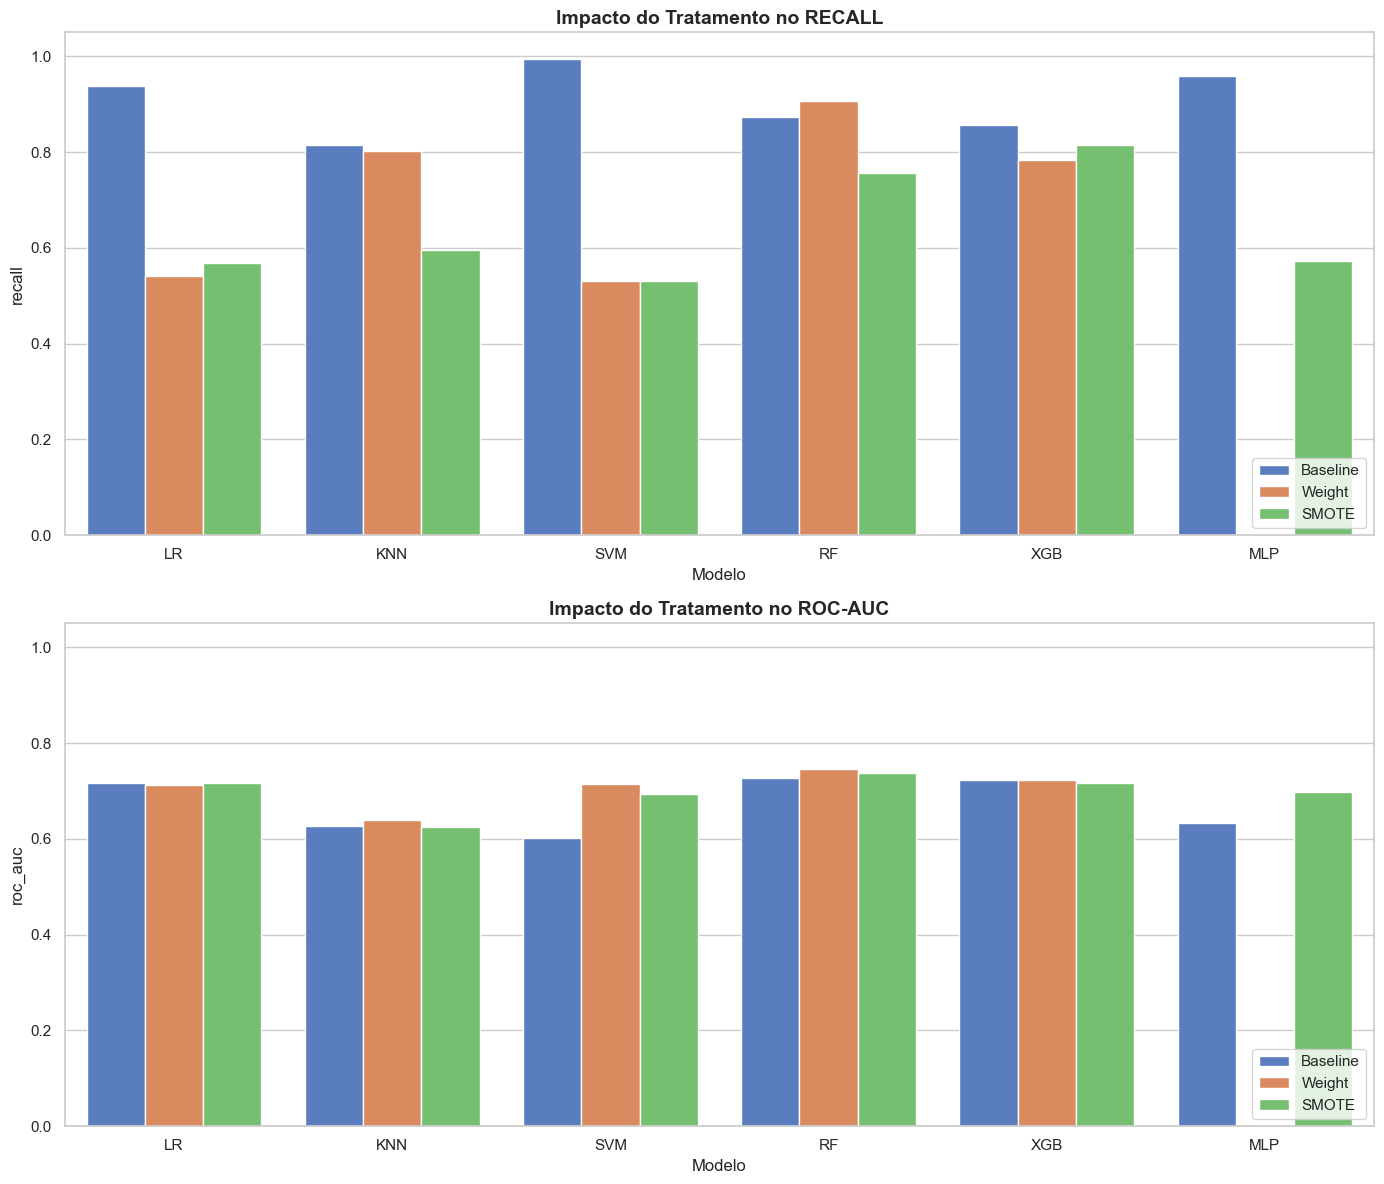

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(data=df_resultados, x='Modelo', y='recall', hue='Estratégia', ax=axes[0], palette='muted')
axes[0].set_title('Impacto do Tratamento no RECALL', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

sns.barplot(data=df_resultados, x='Modelo', y='roc_auc', hue='Estratégia', ax=axes[1], palette='muted')
axes[1].set_title('Impacto do Tratamento no ROC-AUC', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8.5 — Conclusão da Fase 8

Nesta fase analisamos o impacto do desbalanceamento através de pesos e SMOTE. A partir das métricas observadas na tabela de Validação Cruzada:
1. **O que ajudou:** (Será analisado com base nos gráficos: geralmente *class_weight* melhora o ROC-AUC de modelos lineares e SMOTE pode melhorar o *Recall* sacrificando um pouco da *Precision*).
2. **Escolha dos Candidatos para a Fase 10 (Hiperparâmetros):** Vamos selecionar os 2 ou 3 modelos e as respectivas estratégias de tratamento que apresentaram os resultados mais robustos (maior Recall sem despencar o ROC-AUC).

### Checklist de Conclusão da Fase 8
- ✅ Experimentos com Baseline, `class_weight` e `SMOTE` executados.
- ✅ *Data Leakage* evitado com a utilização de `imblearn.pipeline`.
- ✅ Resultados comparados lado a lado (Tabelas dinâmicas e Gráficos).